In [1]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/ckasemtantikul/Library/CloudStorage/OneDrive-WashingtonUniversityinSt.Louis/Documents/PhD/NV Compact Magnetometer/nv_magnetometer_project


# Import and setup

In [2]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

Connected to RFSoC at 192.168.0.103


In [3]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 5000
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500
default_config.readout_integration_tus = 213  # max ~106.7 µs; auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout int.:    {default_config.readout_integration_tus:.2f} µs  ({default_config.readout_integration_treg} treg)")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         5000
  Relax delay:     501 ns
  Readout int.:    213.00 µs  (65434 treg)


In [4]:
# ===== DSA ATTENUATION SETUP (fix 8100-count railing) =====
# Retrieve the soc proxy from qickdawg
import qickdawg as qd
soc = qd.soc  # Access the global soc proxy from start_client()

# Apply DSA to ADC_D (NV PL channel, block "00")
dsa_db = 0  # Start with 6 dB; tune as needed (0-27 dB)
soc.set_adc_attenuator("00", dsa_db)
confirmed_db = soc.get_adc_attenuator("00")
print(f"✓ ADC_D DSA set to {confirmed_db} dB")
print(f"  Expected peak PL: ~{int(8100 * 10**(-confirmed_db/20))} counts (was ~8100)")

✓ ADC_D DSA set to 0.0 dB
  Expected peak PL: ~8100 counts (was ~8100)


# PL Readout

## Both Channel Live

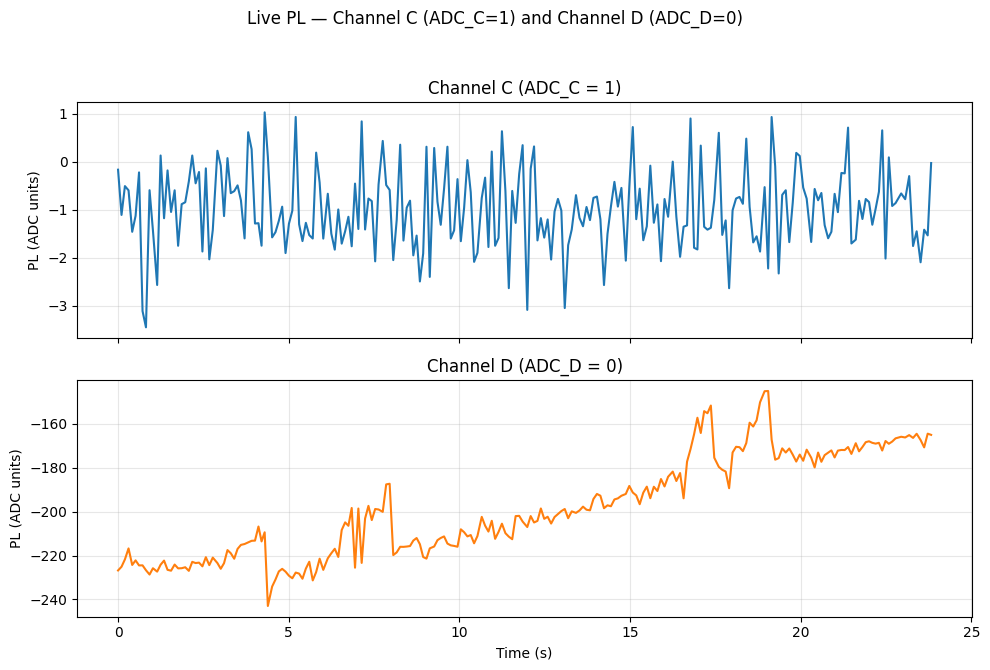

Live PL stopped.


In [11]:
from qickdawg.nvpulsing.nv_live_helpers import run_fast_pl_no_display, run_live_odmr

# Live PL — original single-point acquisition.
# Each call to PLIntensity.acquire() returns one averaged value per channel (reps=cfg.reps).
# ~165 ms per displayed point. Stop with Interrupt (■).

from collections import deque
from time import perf_counter
from IPython.display import display as _ipy_display

cfg_c = copy(default_config); cfg_c.adc_channel = 1  # ADC_C
cfg_d = copy(default_config); cfg_d.adc_channel = 0  # ADC_D
prog_c = qd.PLIntensity(cfg_c)
prog_d = qd.PLIntensity(cfg_d)

n_pts = 400
t_c, d_c = deque(maxlen=n_pts), deque(maxlen=n_pts)
t_d, d_d = deque(maxlen=n_pts), deque(maxlen=n_pts)

plt.ion()
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle('Live PL — Channel C (ADC_C=1) and Channel D (ADC_D=0)')
line_c, = axes[0].plot([], [], 'C0')
line_d, = axes[1].plot([], [], 'C1')
for ax in axes:
    ax.set_ylabel('PL (ADC units)'); ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Time (s)')
handle = _ipy_display(fig, display_id=True)

t0 = perf_counter()
try:
    while True:
        t = perf_counter() - t0
        val_c = prog_c.acquire()  # PLIntensity.acquire() — averages reps, returns one float
        val_d = prog_d.acquire()
        t_c.append(t); d_c.append(val_c)
        t_d.append(t); d_d.append(val_d)
        line_c.set_data(list(t_c), list(d_c))
        line_d.set_data(list(t_d), list(d_d))
        axes[0].set_title('Channel C (ADC_C = 1)'); axes[0].relim(); axes[0].autoscale_view()
        axes[1].set_title('Channel D (ADC_D = 0)'); axes[1].relim(); axes[1].autoscale_view()
        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        fig.canvas.draw_idle()
        handle.update(fig)
except KeyboardInterrupt:
    print('Live PL stopped.')
finally:
    plt.ioff(); plt.close(fig)


## Fast PL Readout

In [ ]:
# PL acquisition — hardware-rate, no display overhead.
# Runs for duration_sec seconds, then saves to CSV.
# Stop early with Interrupt (■).

fast_pl_filename = "fast_PL_dual_channel.csv"
df_fast_pl = run_fast_pl_no_display(
    default_config,
    duration_sec=120,   # 2 minutes; set None to run until interrupted
    batch_size=5000,
    csv_filename=fast_pl_filename,
)
n = len(df_fast_pl)
t_total = float(df_fast_pl["time_s"].iloc[-1]) if n else 0
print(f"Collected {n} points in {t_total:.2f} s  →  {n/t_total:.0f} pts/s" if t_total > 0 else f"{n} points")
